# ShipmentSure: Predicting On-Time Delivery Using Supplier Data


# Loading the Dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prachi13/customer-analytics")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-analytics' dataset.
Path to dataset files: /kaggle/input/customer-analytics


# Libaray for data analysis and visualization

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading the Dataset**

In [6]:
df = pd.read_csv('/kaggle/input/customer-analytics/Train.csv')


# Visulizating the first and last 10 data in the dataset

In [ ]:
df.head(10)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
5,6,F,Flight,3,1,162,3,medium,F,12,1417,1
6,7,D,Flight,3,4,250,3,low,F,3,2371,1
7,8,F,Flight,4,1,233,2,low,F,48,2804,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
9,10,B,Flight,3,2,164,3,medium,F,29,1187,1


In [ ]:
df.tail(10)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
10989,10990,B,Ship,5,1,218,5,medium,F,9,1603,0
10990,10991,C,Ship,5,4,219,6,low,M,3,1098,0
10991,10992,F,Ship,5,2,261,5,medium,M,9,1227,1
10992,10993,D,Ship,5,1,236,5,medium,M,3,1906,0
10993,10994,F,Ship,5,1,257,6,low,F,1,1150,0
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0
10998,10999,D,Ship,2,5,155,5,low,F,6,1639,0


# Information of the data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [ ]:
df.shape

(10999, 12)

# Attributes of the dataset

In [ ]:
df.columns.to_list()

['ID',
 'Warehouse_block',
 'Mode_of_Shipment',
 'Customer_care_calls',
 'Customer_rating',
 'Cost_of_the_Product',
 'Prior_purchases',
 'Product_importance',
 'Gender',
 'Discount_offered',
 'Weight_in_gms',
 'Reached.on.Time_Y.N']

# Description of the dataset
* Count    
* Mean
* Std
* min
* 25%, 50%, 75%
* max


In [ ]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


# groupby in Warehouse_block

In [ ]:
df.groupby('Warehouse_block').sum()

,ID,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
Warehouse_block,,,,,,,,,,,
A,10079667,FlightFlightFlightShipShipShipShipShipShipShip...,7402,5421,382671,6558,lowlowlowmediumhighlowlowlowlowlowmediummedium...,MFMFFFFMMFMFFFMFMMMMMMFMMMMMFMFFFMMMMFFFMFFFFF...,24237,6627118,1075
B,10081500,FlightFlightFlightShipShipShipShipShipShipShip...,7369,5463,388888,6553,mediummediumlowmediummediummediumlowlowlowmedi...,MFFFMMFFMFMMFMFFMMFFFMFMFMFFFMFFFFMFMFFMMFFFMF...,24172,6664240,1104
C,10083333,FlightFlightFlightShipShipShipShipShipShipShip...,7451,5488,387114,6516,mediummediummediumlowlowmediumlowmediumlowhigh...,FMFMMFMFFMMMFFMFMMMFMFFMMFMFMFMMMMMFMMMFFFMFFM...,24562,6674560,1094
D,10087000,FlightFlightFlightShipShipShipShipShipShipShip...,7434,5535,386805,6606,lowlowmediumhighmediummediumhighmediummediumhi...,FFFMFFFMMMFFFMFFMMFMFMMMFFMFFFFFFFMFMMMFMFMFMF...,24014,6655305,1096
F,20163000,FlightFlightFlightFlightFlightShipShipShipShip...,14939,10986,766477,13007,lowmediumlowmediumhighmediummediumhighlowlowlo...,MFFFMMMMMFFFFMMMFMMFMMFFFFFFMFFMFMMMMMMMFMFMFM...,50107,13349327,2194


In [ ]:
df.groupby('Warehouse_block').count()

,ID,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
Warehouse_block,,,,,,,,,,,
A,1833,1833,1833,1833,1833,1833,1833,1833,1833,1833,1833
B,1833,1833,1833,1833,1833,1833,1833,1833,1833,1833,1833
C,1833,1833,1833,1833,1833,1833,1833,1833,1833,1833,1833
D,1834,1834,1834,1834,1834,1834,1834,1834,1834,1834,1834
F,3666,3666,3666,3666,3666,3666,3666,3666,3666,3666,3666


In [ ]:
df.groupby('Warehouse_block').size()

,0
Warehouse_block,
A,1833
B,1833
C,1833
D,1834
F,3666


In [ ]:
df.groupby("Product_importance").count()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
Product_importance,,,,,,,,,,,
high,948,948,948,948,948,948,948,948,948,948,948
low,5297,5297,5297,5297,5297,5297,5297,5297,5297,5297,5297
medium,4754,4754,4754,4754,4754,4754,4754,4754,4754,4754,4754


In [ ]:
df.groupby('Mode_of_Shipment').count()

,ID,Warehouse_block,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
Mode_of_Shipment,,,,,,,,,,,
Flight,1777,1777,1777,1777,1777,1777,1777,1777,1777,1777,1777
Road,1760,1760,1760,1760,1760,1760,1760,1760,1760,1760,1760
Ship,7462,7462,7462,7462,7462,7462,7462,7462,7462,7462,7462


# From this we can able to find the mode of shipment was high in ship

In [ ]:
df.groupby('Mode_of_Shipment').size()

,0
Mode_of_Shipment,
Flight,1777
Road,1760
Ship,7462


# Query based analysis

**The list of details which are belonged to based "A" which have high product importance and reached on time**

In [ ]:
df[
    (df["Product_importance"] == "high") &
    (df["Reached.on.Time_Y.N"] == 1) &
    (df["Warehouse_block"] == "A")
]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
26,27,A,Ship,4,1,172,3,high,F,24,1066,1
116,117,A,Road,4,1,150,4,high,M,60,1024,1
140,141,A,Flight,4,4,264,3,high,M,59,2020,1
158,159,A,Ship,5,5,205,2,high,M,65,3671,1
176,177,A,Ship,4,5,192,3,high,M,20,3872,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10322,10323,A,Ship,2,1,96,2,high,F,9,4449,1
10400,10401,A,Road,2,1,235,3,high,M,8,4522,1
10898,10899,A,Ship,4,1,222,2,high,M,3,5665,1
10910,10911,A,Ship,5,5,264,8,high,F,10,5759,1


**The list of detials which belongs to block "A" and shiped through Road and have product importance High**

In [ ]:
df[(df["Mode_of_Shipment"] == "Road")&(df["Product_importance"] == "high")&(df["Warehouse_block"]=="A")]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
116,117,A,Road,4,1,150,4,high,M,60,1024,1
530,531,A,Road,3,2,237,2,high,M,26,3103,1
536,537,A,Road,2,3,154,4,high,F,17,1897,1
1070,1071,A,Road,3,4,250,2,high,M,61,3207,1
1622,1623,A,Road,3,1,180,3,high,F,21,1047,1
1634,1635,A,Road,6,3,241,6,high,F,8,3878,1
1754,1755,A,Road,6,5,260,4,high,M,10,2756,1
2048,2049,A,Road,3,2,185,2,high,F,49,3864,1
2180,2181,A,Road,4,1,242,3,high,M,47,3489,1
2312,2313,A,Road,4,4,184,3,high,F,27,3967,1


**The details about the productes count based on the importance of the product**

In [ ]:
df.groupby('Product_importance').size()

,0
Product_importance,
high,948
low,5297
medium,4754


**To see the shipment details baseed on the mode of shipment and product importnce to find the average cost of the product and average weight of the product**

In [ ]:
summary = df.groupby(["Mode_of_Shipment", "Product_importance"]).agg({
    "Weight_in_gms": ["mean", "max", "min"],
    "Cost_of_the_Product": ["mean", "max", "min"]
}).reset_index()

print(summary)

  Mode_of_Shipment Product_importance Weight_in_gms              \
                                               mean   max   min   
0           Flight               high   4069.871166  5997  1029   
1           Flight                low   3536.021480  5987  1009   
2           Flight             medium   3637.667526  5983  1001   
3             Road               high   3974.487342  5991  1024   
4             Road                low   3498.372229  6000  1005   
5             Road             medium   3754.543624  6614  1002   
6             Ship               high   3996.658692  6000  1007   
7             Ship                low   3488.314270  5999  1001   
8             Ship             medium   3720.112280  7846  1003   

  Cost_of_the_Product            
                 mean  max  min  
0          202.564417  289   99  
1          210.875895  310   97  
2          209.028351  310   96  
3          203.050633  291  105  
4          210.421237  310   97  
5          212.112752  3

**To see the detials of the product with minimum and maximum cost of the product**

In [ ]:
df.loc[df["Cost_of_the_Product"].idxmin()]

,431
ID,432
Warehouse_block,F
Mode_of_Shipment,Ship
Customer_care_calls,4
Customer_rating,2
Cost_of_the_Product,96
Prior_purchases,3
Product_importance,low
Gender,M
Discount_offered,22


In [ ]:

df.loc[df["Cost_of_the_Product"].idxmax()]

,4551
ID,4552
Warehouse_block,B
Mode_of_Shipment,Ship
Customer_care_calls,6
Customer_rating,2
Cost_of_the_Product,310
Prior_purchases,4
Product_importance,medium
Gender,F
Discount_offered,5


**The detials of the shipment with the high importance and mode of shipment ship with some other conditions

In [ ]:
df[(df["Mode_of_Shipment"] == "Ship")&(df["Product_importance"] == "high")&(df["Warehouse_block"]=="A")&(df["Customer_rating"]==5)&(df["Customer_care_calls"]==5)]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
158,159,A,Ship,5,5,205,2,high,M,65,3671,1
4970,4971,A,Ship,5,5,233,3,high,M,5,5330,0
5234,5235,A,Ship,5,5,271,4,high,M,10,4305,1
5846,5847,A,Ship,5,5,193,5,high,F,4,5087,1
9230,9231,A,Ship,5,5,253,2,high,F,3,4851,0
10910,10911,A,Ship,5,5,264,8,high,F,10,5759,1


**Detials if the shiment with low and high discount**

In [ ]:
# For Low discount (min discount)
max_low = df.loc[df["Discount_offered"].idxmin()]

# For High discount (max discount)
max_high = df.loc[df["Discount_offered"].idxmax()]

print(max_low)

print(max_high)

ID                         13
Warehouse_block             D
Mode_of_Shipment       Flight
Customer_care_calls         3
Customer_rating             5
Cost_of_the_Product       198
Prior_purchases             3
Product_importance     medium
Gender                      F
Discount_offered            1
Weight_in_gms            3667
Reached.on.Time_Y.N         1
Name: 12, dtype: object
ID                      112
Warehouse_block           B
Mode_of_Shipment       Road
Customer_care_calls       4
Customer_rating           2
Cost_of_the_Product     239
Prior_purchases           3
Product_importance      low
Gender                    F
Discount_offered         65
Weight_in_gms          3679
Reached.on.Time_Y.N       1
Name: 111, dtype: object


# EDA(Exploratory Data Analysis)
It is the process of analyzing datasets to summarize their main characteristics, often using visual methods, before applying machine learning or statistical models.


* Understand the data – structure, format, and meaning of attributes.

* Identify patterns & relationships – correlations, distributions, trends.

* Detect anomalies/outliers – unusual data points.

* Test assumptions – check normality, variance, etc.

* Prepare for modeling – feature selection, transformation, handling missing values.

# To find the Correlation between the attributes with num datatype

In [ ]:
df.select_dtypes(include=np.number).corr()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
ID,1.000000,0.188998,-0.005722,0.196791,0.145369,-0.598278,0.278312,-0.411822
Customer_care_calls,0.188998,1.000000,0.012209,0.323182,0.180771,-0.130750,-0.276615,-0.067126
Customer_rating,-0.005722,0.012209,1.000000,0.009270,0.013179,-0.003124,-0.001897,0.013119
Cost_of_the_Product,0.196791,0.323182,0.009270,1.000000,0.123676,-0.138312,-0.132604,-0.073587
Prior_purchases,0.145369,0.180771,0.013179,0.123676,1.000000,-0.082769,-0.168213,-0.055515
Discount_offered,-0.598278,-0.130750,-0.003124,-0.138312,-0.082769,1.000000,-0.376067,0.397108
Weight_in_gms,0.278312,-0.276615,-0.001897,-0.132604,-0.168213,-0.376067,1.000000,-0.268793
Reached.on.Time_Y.N,-0.411822,-0.067126,0.013119,-0.073587,-0.055515,0.397108,-0.268793,1.000000


Correlation is a statistical measure that shows the strength and direction of the linear relationship between two variables. Its value ranges from -1 to +1, where +1 indicates a perfect positive relationship, -1 indicates a perfect negative relationship, and 0 means no linear relationship. In EDA, correlation is widely used because it helps to identify patterns, detect multicollinearity, and select important features for modeling. Since it is standardized, correlation is easier to interpret than covariance and provides clear insights into how variables are related.

# Analysis from corealations

Discount_offered shows the strongest positive correlation with delayed deliveries, indicating that higher discounts are often linked with late shipments, possibly due to bulk or low-priority orders. Weight_in_gms has a moderate negative correlation, suggesting that heavier shipments are less likely to reach on time. Other attributes such as customer rating, prior purchases, and product cost show very weak or negligible correlations, meaning they have minimal influence on delivery punctuality. This highlights that discount and weight are the most significant factors in predicting on-time delivery.

In [ ]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

# 1. Distribution of Numeric Features

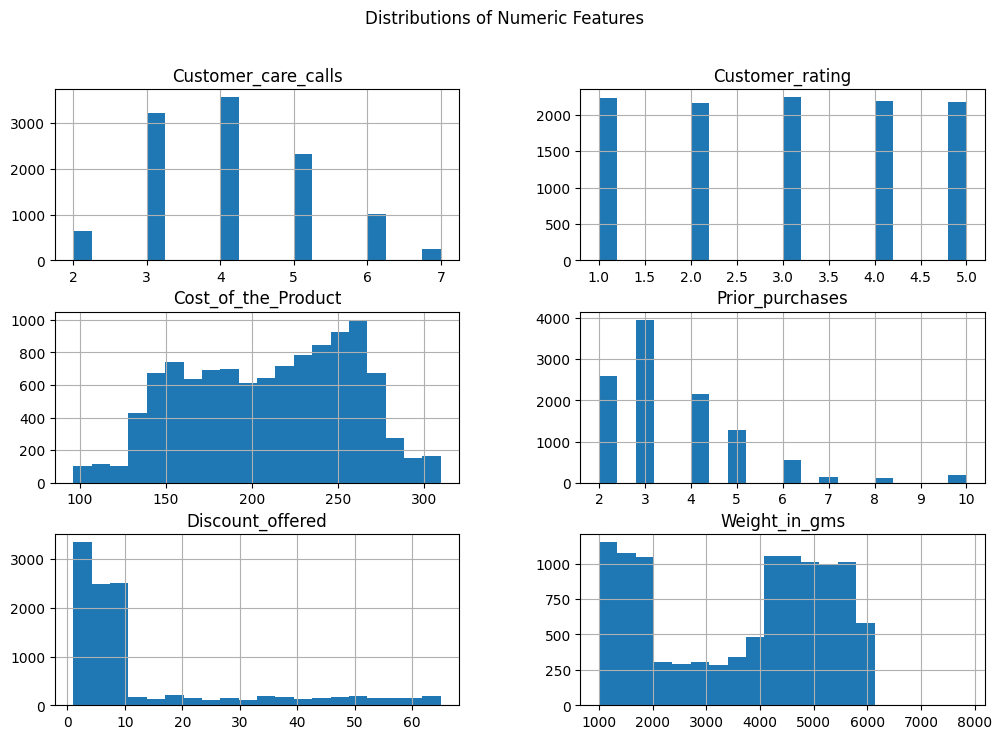

In [ ]:
num_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
            'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

df[num_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Distributions of Numeric Features")
plt.show()

# 2. Correlation Heatmap (Numerical Features)

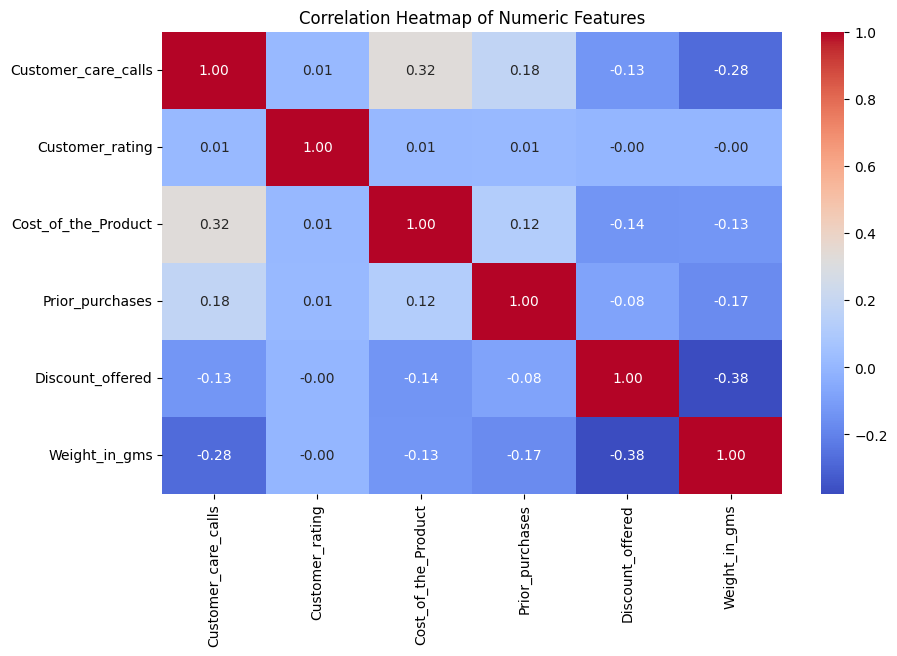

In [ ]:
plt.figure(figsize=(10, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

A heatmap is a graphical representation that shows the relationship between variables using colors. In this project, it is used to visualize correlations among shipment attributes such as cost, weight, discounts, and customer care calls. It helps to quickly identify strong or weak relationships, remove redundant features, and focus on the most important factors for predicting on-time delivery.

# 3. Weight vs Cost (Boxplot per Shipment Mode)

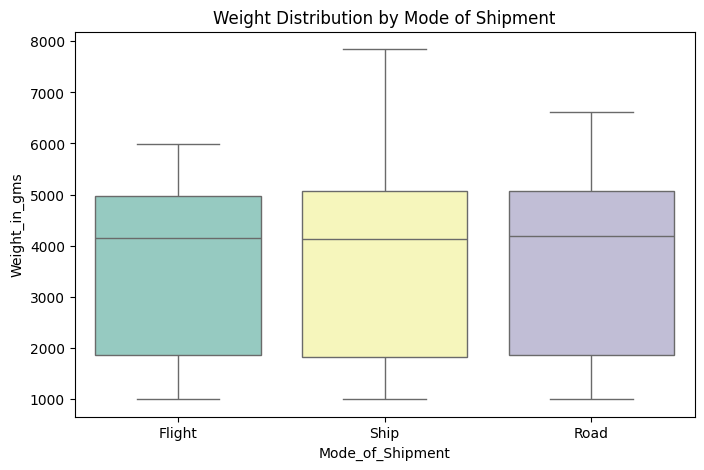

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Mode_of_Shipment", y="Weight_in_gms",
            hue="Mode_of_Shipment", palette="Set3", legend=False)

plt.title("Weight Distribution by Mode of Shipment")
plt.show()


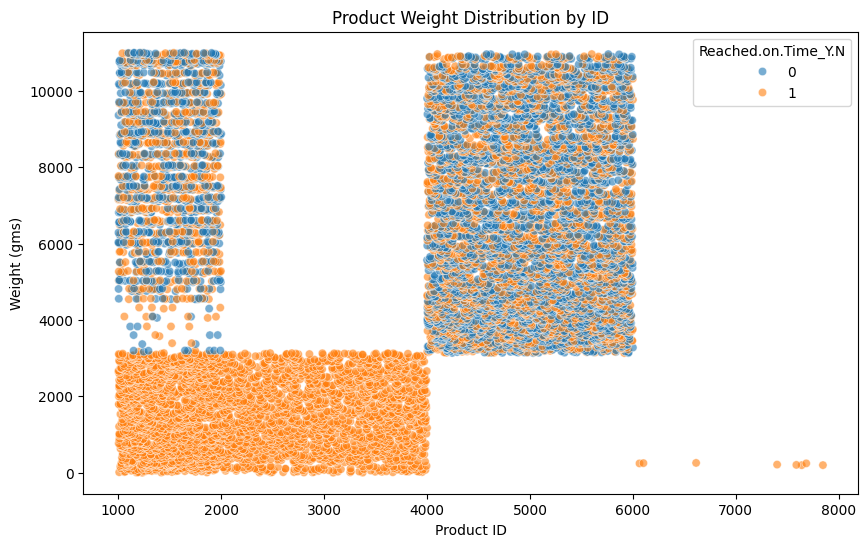

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Weight_in_gms", y="ID", alpha=0.6,hue="Reached.on.Time_Y.N")

plt.title("Product Weight Distribution by ID")
plt.xlabel("Product ID")
plt.ylabel("Weight (gms)")
plt.show()

From this we can able to see the the product weight which was between 0 to 3000 grams are delivered on time

# Visulization on the data based on the reach on time attribute

# 1. Countplot – On-time vs Not on-time

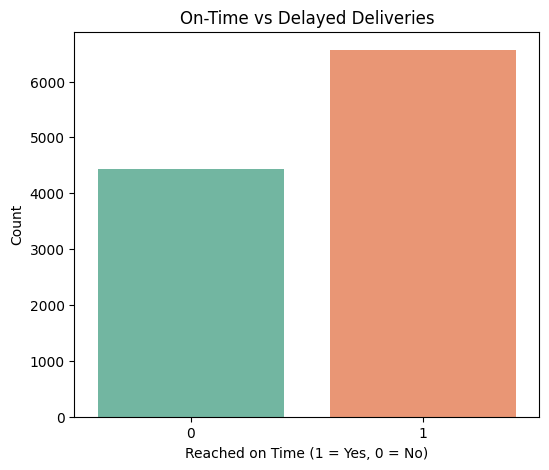

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="Reached.on.Time_Y.N", hue="Reached.on.Time_Y.N", palette="Set2", legend=False)
plt.title("On-Time vs Delayed Deliveries")
plt.xlabel("Reached on Time (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()


#2. Barplot – Average Cost vs On-time Delivery

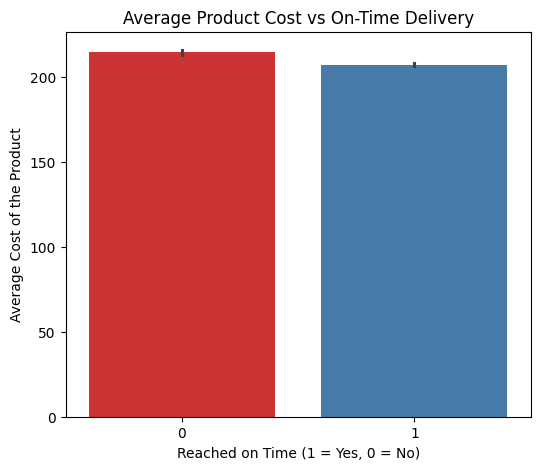

In [ ]:
plt.figure(figsize=(6,5))
sns.barplot(
    data=df,
    x="Reached.on.Time_Y.N",
    y="Cost_of_the_Product",
    hue="Reached.on.Time_Y.N",
    palette="Set1",
    legend=False
)
plt.title("Average Product Cost vs On-Time Delivery")
plt.xlabel("Reached on Time (1 = Yes, 0 = No)")
plt.ylabel("Average Cost of the Product")
plt.show()


# 3. Boxplot – Weight vs On-time Delivery

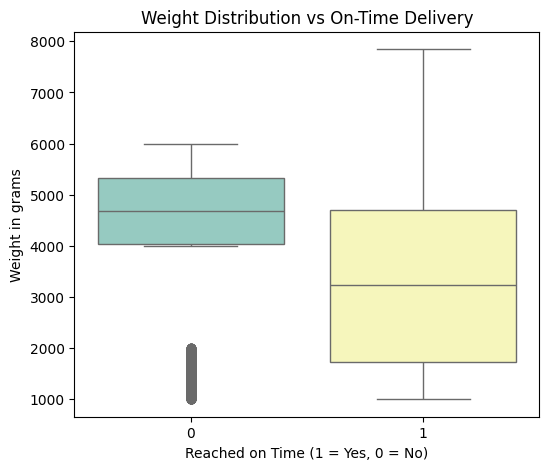

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(
    data=df,
    x="Reached.on.Time_Y.N",
    y="Weight_in_gms",
    hue="Reached.on.Time_Y.N",
    palette="Set3",
    legend=False
)
plt.title("Weight Distribution vs On-Time Delivery")
plt.xlabel("Reached on Time (1 = Yes, 0 = No)")
plt.ylabel("Weight in grams")
plt.show()


from this we can able to see the productes which deliver on time and which may not accroding to the weight of the product

# 4. Heatmap – Correlation with On-time Delivery

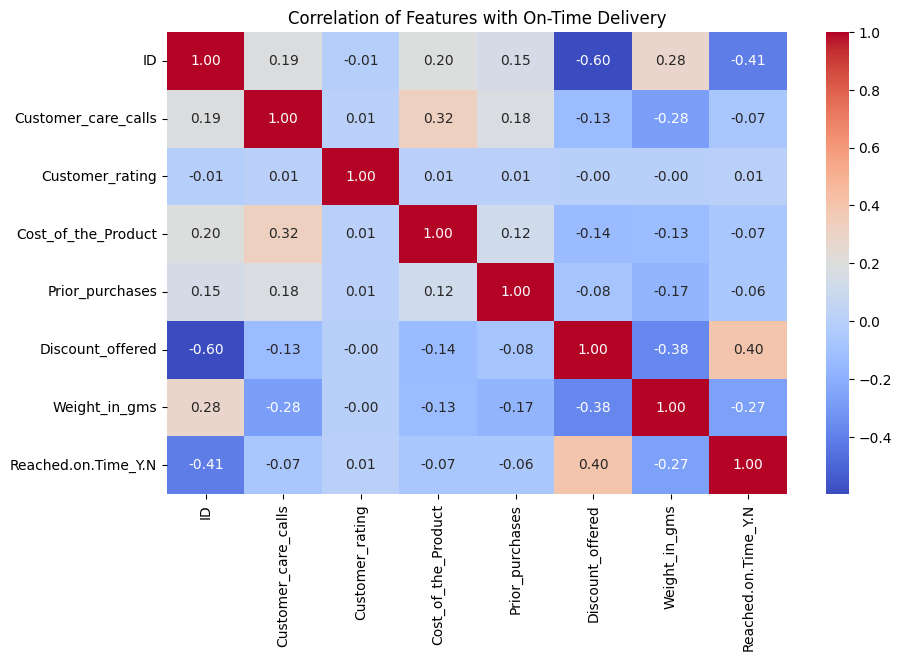

In [ ]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Features with On-Time Delivery")
plt.show()


A heatmap is a visual tool used to show the strength of relationships between different numerical features in the dataset. In this project, the heatmap highlights how factors such as Weight, Cost of the Product, Customer Rating, Prior Purchases, and Discount Offered correlate with the target variable Reached.on.Time_Y.N (on-time delivery).
By analyzing the color intensity, we can quickly identify which features are strongly or weakly related to delivery performance. For example, higher product weight or larger discounts may show stronger associations with delays, while factors like customer rating may have little impact.
This helps in feature selection and model building, as we can prioritize the attributes that most influence on-time delivery for ShipmentSure: Predicting On-Time Delivery Using Supplier Data.

# Some more visulization of data

# Discount Offered vs Cost of Product

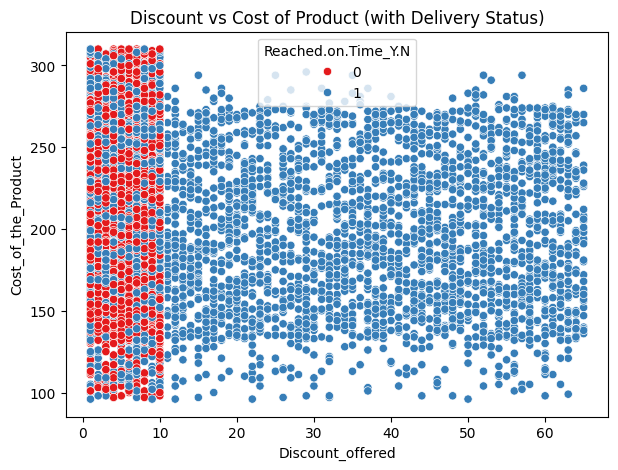

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Discount_offered", y="Cost_of_the_Product", hue="Reached.on.Time_Y.N", palette="Set1")
plt.title("Discount vs Cost of Product (with Delivery Status)")
plt.show()

from this we can see that the discount value was more than 10 are reached on time

# Shipment Mode Analysis

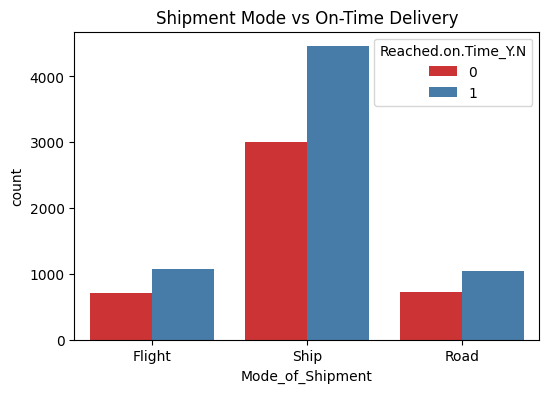

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Mode_of_Shipment", hue="Reached.on.Time_Y.N", palette="Set1")
plt.title("Shipment Mode vs On-Time Delivery")
plt.show()

 # Product Importance vs Delivery

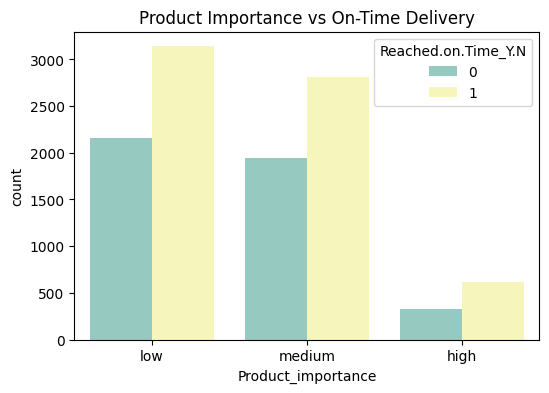

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Product_importance", hue="Reached.on.Time_Y.N", palette="Set3")
plt.title("Product Importance vs On-Time Delivery")
plt.show()

# Feature Engineering

Feature engineering is the process of transforming raw data into meaningful inputs that improve the performance of machine learning models. It involves creating, modifying, or selecting features to better capture the underlying patterns in the data. Common techniques include handling missing values, encoding categorical variables, scaling and normalizing numerical data, generating interaction or polynomial features, and extracting domain-specific attributes such as time-based features in time series or TF-IDF in text data. Effective feature engineering often requires both technical skill and domain knowledge, since the quality of features has a direct impact on how well a model can learn and generalize.

In [ ]:
df["Final_Effective_Cost"] = df["Cost_of_the_Product"] * (1 - df["Discount_offered"]/100)

print(df)

          ID Warehouse_block Mode_of_Shipment  Customer_care_calls  \
0          1               D           Flight                    4   
1          2               F           Flight                    4   
2          3               A           Flight                    2   
3          4               B           Flight                    3   
4          5               C           Flight                    2   
...      ...             ...              ...                  ...   
10994  10995               A             Ship                    4   
10995  10996               B             Ship                    4   
10996  10997               C             Ship                    5   
10997  10998               F             Ship                    5   
10998  10999               D             Ship                    2   

       Customer_rating  Cost_of_the_Product  Prior_purchases  \
0                    2                  177                3   
1                    5         

The Final_Effective_Cost is a derived feature that represents the actual price a customer pays after applying a percentage discount on a product. It provides a more accurate measure of customer spending compared to considering only the original cost or discount separately. This feature is useful in both analysis and predictive modeling, as it simplifies data by combining two correlated variables into one meaningful value. It helps businesses understand the real transaction value, analyze the effect of discounts on sales and profitability, and improve model performance when predicting outcomes such as delivery success or customer satisfaction.

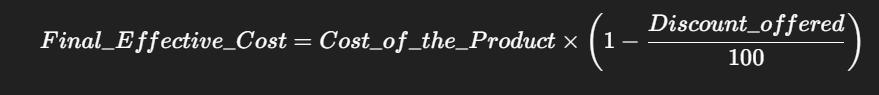

# **Logistic Regression (Predicting Delivery On Time)**
Logistic Regression is a supervised machine learning algorithm used for classification tasks where the target variable is categorical (often binary). Instead of predicting a continuous value, Logistic Regression predicts the probability that a given input belongs to a particular class. It uses the logistic (sigmoid) function to map predictions between 0 and 1, which can then be interpreted as probabilities and converted into class labels.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("/kaggle/input/customer-analytics/Train.csv")

# Features and target
X = df.drop(columns=["ID", "Reached.on.Time_Y.N"])
y = df["Reached.on.Time_Y.N"]

# Categorical and numerical columns
cat_cols = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender"]
num_cols = [col for col in X.columns if col not in cat_cols]

# Preprocessing (OneHotEncoding for categorical)
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), cat_cols)
], remainder="passthrough")

# Logistic Regression pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6413636363636364
              precision    recall  f1-score   support

           0       0.56      0.56      0.56       895
           1       0.70      0.70      0.70      1305

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In your dataset, Logistic Regression is well-suited for predicting Reached.on.Time_Y.N, which indicates whether a product delivery was on time (0) or late (1). Features such as shipment mode, customer care calls, product importance, discount, and weight can all influence delivery timeliness. Logistic Regression is used here because it is simple, interpretable, and effective for binary outcomes, making it a good choice for understanding and classifying delivery performance.

# **Linear Regression (Predicting Product Cost)**
Linear Regression is a supervised machine learning algorithm used to predict a continuous target variable based on one or more independent features. It assumes a linear relationship between the input variables and the target, meaning the target can be expressed as a weighted sum of the features plus an error term. The goal of Linear Regression is to find the best-fitting line (or hyperplane in higher dimensions) that minimizes the difference between the predicted and actual values.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Target = Cost of Product
X = df.drop(columns=["ID", "Cost_of_the_Product"])
y = df["Cost_of_the_Product"]

# Categorical + numerical preprocessing same as above
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 1985.7494204612744
RMSE: 44.56174839995929
R2 Score: 0.10408262701335558


In the context of your dataset, Linear Regression can be used when the target variable is continuous, such as Cost_of_the_Product or Weight_in_gms. For example, you might want to predict the cost of a product based on its weight, discount offered, and prior purchases. Linear Regression is useful here because it gives both predictions and insights into how strongly each feature influences the target variable, which helps in understanding business patterns such as how discounts or product weight affect cost.

# **Linear Regression Line**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


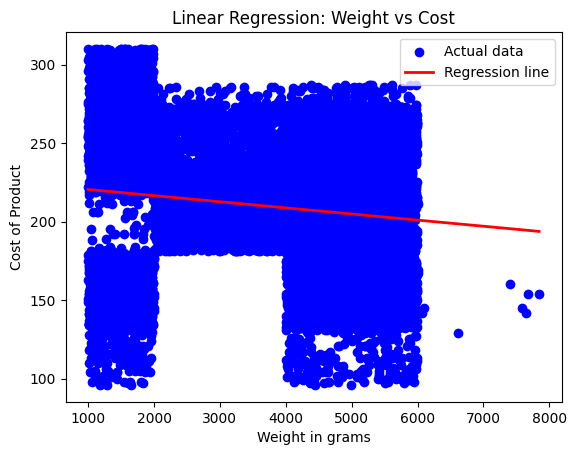

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Load dataset
df = pd.read_csv("/kaggle/input/customer-analytics/Train.csv")

# Choose one feature and target
X = df[["Weight_in_gms"]]
y = df["Cost_of_the_Product"]

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Predictions for line
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_pred = model.predict(X_range)

# Plot
plt.scatter(X, y, color="blue", label="Actual data")
plt.plot(X_range, y_pred, color="red", linewidth=2, label="Regression line")
plt.xlabel("Weight in grams")
plt.ylabel("Cost of Product")
plt.title("Linear Regression: Weight vs Cost")
plt.legend()
plt.show()



# **Naive Bayes Classification**
Naïve Bayes Classification is a probabilistic machine learning algorithm based on Bayes’ Theorem, which calculates the probability of a class given a set of features. It makes the “naive” assumption that all features are independent and contribute equally to the outcome. Despite this simplification, it often performs surprisingly well in real-world applications, especially for classification tasks.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("/kaggle/input/customer-analytics/Train.csv")

# Features & target
X = df.drop(columns=["ID", "Reached.on.Time_Y.N"])
y = df["Reached.on.Time_Y.N"]

# Define categorical and numerical columns
cat_cols = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender"]
num_cols = [col for col in X.columns if col not in cat_cols]

# Preprocessing: OneHot for categorical + Scaling for numeric
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

# Naïve Bayes model pipeline
nb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
nb_model.fit(X_train, y_train)

# Predict
y_pred = nb_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6540909090909091
              precision    recall  f1-score   support

           0       0.54      0.99      0.70       895
           1       0.98      0.43      0.59      1305

    accuracy                           0.65      2200
   macro avg       0.76      0.71      0.65      2200
weighted avg       0.80      0.65      0.64      2200



target variable is Reached.on.Time_Y.N (whether a delivery was on time or not), Naïve Bayes is used because it is simple, fast, and effective when working with mixed data types. Your dataset contains both categorical features (such as shipment mode, warehouse block, product importance, and gender) and numerical features (such as cost, discount offered, customer care calls, and weight). Naïve Bayes can handle these efficiently after preprocessing.

# **SVM Classification (Predict Delivery on Time)**
Support Vector Machine (SVM) classification is a supervised machine learning algorithm used for binary and multi-class classification tasks. The main idea of SVM is to find the optimal hyperplane that best separates the classes in the feature space. It does this by maximizing the margin between the closest data points of each class, which are called support vectors. Depending on the data distribution, SVM can use different kernels (linear, polynomial, radial basis function, sigmoid) to transform the data and handle cases where the classes are not linearly separable.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("/kaggle/input/customer-analytics/Train.csv")

# Features & target
X = df.drop(columns=["ID", "Reached.on.Time_Y.N"])
y = df["Reached.on.Time_Y.N"]

# Categorical & numerical columns
cat_cols = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender"]
num_cols = [col for col in X.columns if col not in cat_cols]

# Preprocessing (OneHot + StandardScaler for SVM)
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

# SVM model
svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
svm_model.fit(X_train, y_train)

# Predict
y_pred = svm_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6627272727272727
              precision    recall  f1-score   support

           0       0.56      0.84      0.67       895
           1       0.83      0.54      0.66      1305

    accuracy                           0.66      2200
   macro avg       0.69      0.69      0.66      2200
weighted avg       0.72      0.66      0.66      2200



the target variable is Reached.on.Time_Y.N (on-time delivery vs late delivery), SVM classification is used because it is effective in handling high-dimensional data and can work well with a mixture of categorical and numerical features once they are properly preprocessed. It is particularly useful when the data is not linearly separable, as the kernel trick allows SVM to map the features into a higher-dimensional space and create complex decision boundaries.

# **SVM Regression (Predict Product Cost)**

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Features & target
X = df.drop(columns=["ID", "Cost_of_the_Product"])
y = df["Cost_of_the_Product"]

# Categorical & numerical columns
# Drop 'Reached.on.Time_Y.N' from X before defining columns
X = X.drop(columns=["Reached.on.Time_Y.N"])
cat_cols = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender"]
num_cols = [col for col in X.columns if col not in cat_cols]


# Preprocessing
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

# SVR model
svr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
svr_model.fit(X_train, y_train)

# Predict
y_pred = svr_model.predict(X_test)

# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 1631.5902269646995
RMSE: 40.39294773799877
R2 Score: 0.26386984436669836


# **Ensemble Learning for Classification**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("/kaggle/input/customer-analytics/Train.csv")

# Features and target
X = df.drop(columns=["ID", "Reached.on.Time_Y.N"])
y = df["Reached.on.Time_Y.N"]

# Categorical + numerical columns
cat_cols = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender"]
num_cols = [col for col in X.columns if col not in cat_cols]

# Preprocessing
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

# Models
rf = RandomForestClassifier(n_estimators=200, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)

# Voting Ensemble
ensemble_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", VotingClassifier(estimators=[
        ("rf", rf), ("gb", gb)
    ], voting="soft"))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
ensemble_model.fit(X_train, y_train)

# Predictions
y_pred = ensemble_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.67
              precision    recall  f1-score   support

           0       0.57      0.77      0.65       895
           1       0.79      0.60      0.68      1305

    accuracy                           0.67      2200
   macro avg       0.68      0.69      0.67      2200
weighted avg       0.70      0.67      0.67      2200



# **ROC CURVE**
The ROC (Receiver Operating Characteristic) curve is a graphical representation used to evaluate the performance of a binary classification model. It plots the True Positive Rate (TPR or sensitivity) on the y-axis against the False Positive Rate (FPR or 1-specificity) on the x-axis at various threshold settings. The ROC curve shows how well the model distinguishes between the two classes across different probability thresholds, rather than just using a fixed cutoff (like 0.5).

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


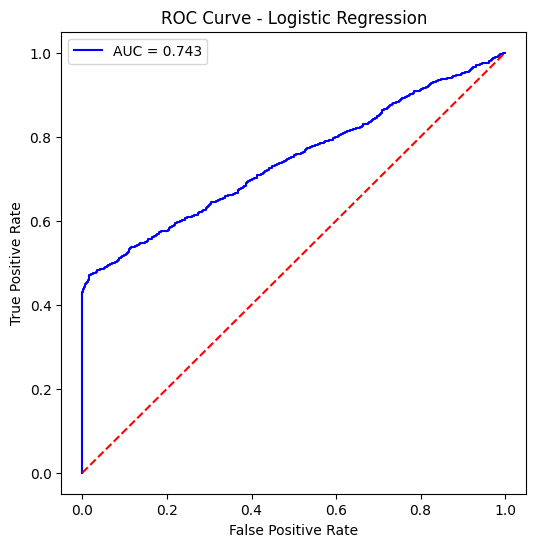

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# Load dataset (replace with your actual dataframe)
# df = pd.read_csv("your_file.csv")

# Features and target
X = df.drop("Reached.on.Time_Y.N", axis=1)
y = df["Reached.on.Time_Y.N"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

# Plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


The ROC (Receiver Operating Characteristic) curve is a graphical representation used to evaluate the performance of a binary classification model. It plots the True Positive Rate (TPR or sensitivity) on the y-axis against the False Positive Rate (FPR or 1-specificity) on the x-axis at various threshold settings. The ROC curve shows how well the model distinguishes between the two classes across different probability thresholds, rather than just using a fixed cutoff (like 0.5).